## Unit 8. Neural Networks and Deep Learning

Fashion classification using images

### 8.1 Fashion Classification

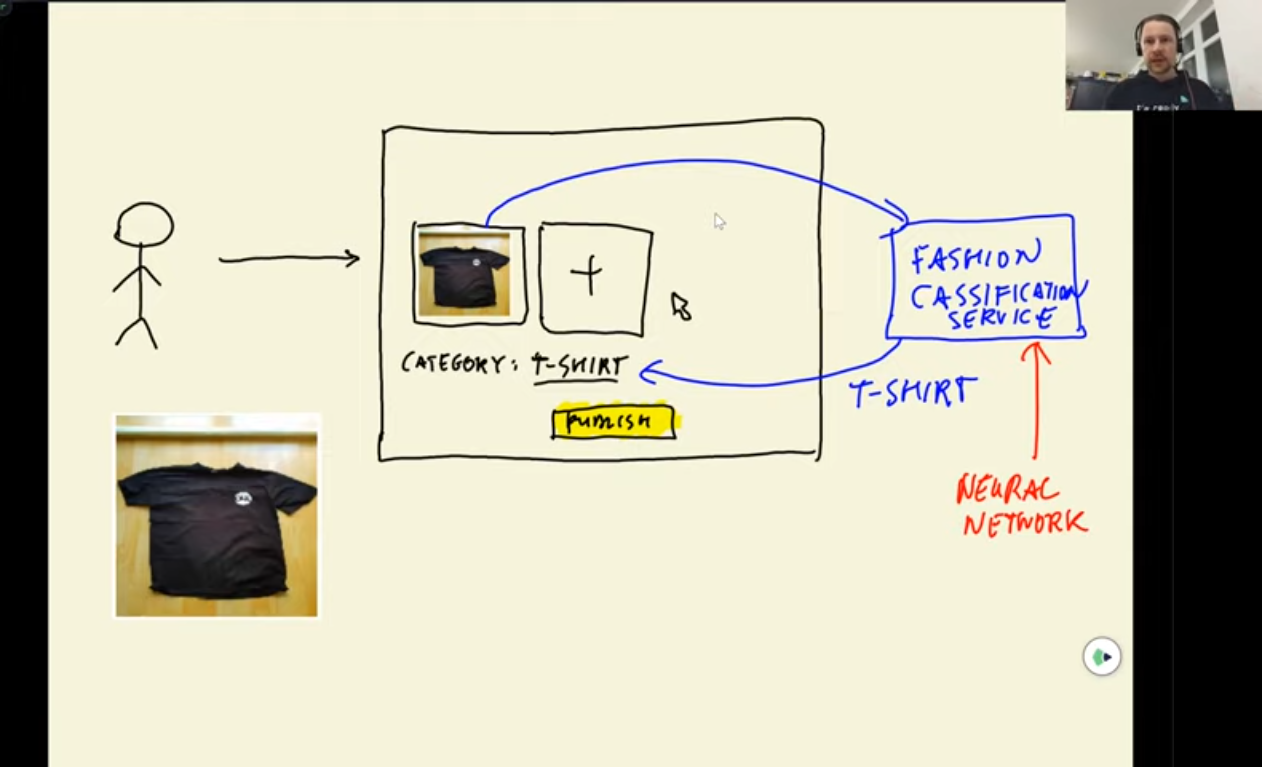

Theory:
https://cs231n.github.io/

### 8.2 TensorFlow and Keras

- Installing TensorFlow
- Loading images

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras

2025-11-25 00:07:36.294460: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 00:07:36.294741: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 00:07:36.330221: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 00:07:37.302352: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [3]:
from tensorflow.keras.preprocessing.image import load_img

In [4]:
path = "./clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
fullname = f'{path}/{name}'
fullname

'./clothing-dataset-small/train/t-shirt/5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'

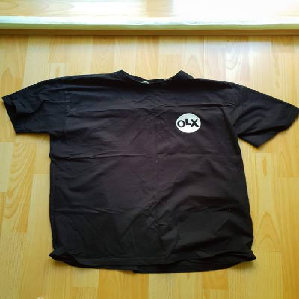

In [7]:
img = load_img(fullname, target_size=(299, 299))
img

Why to specify the size
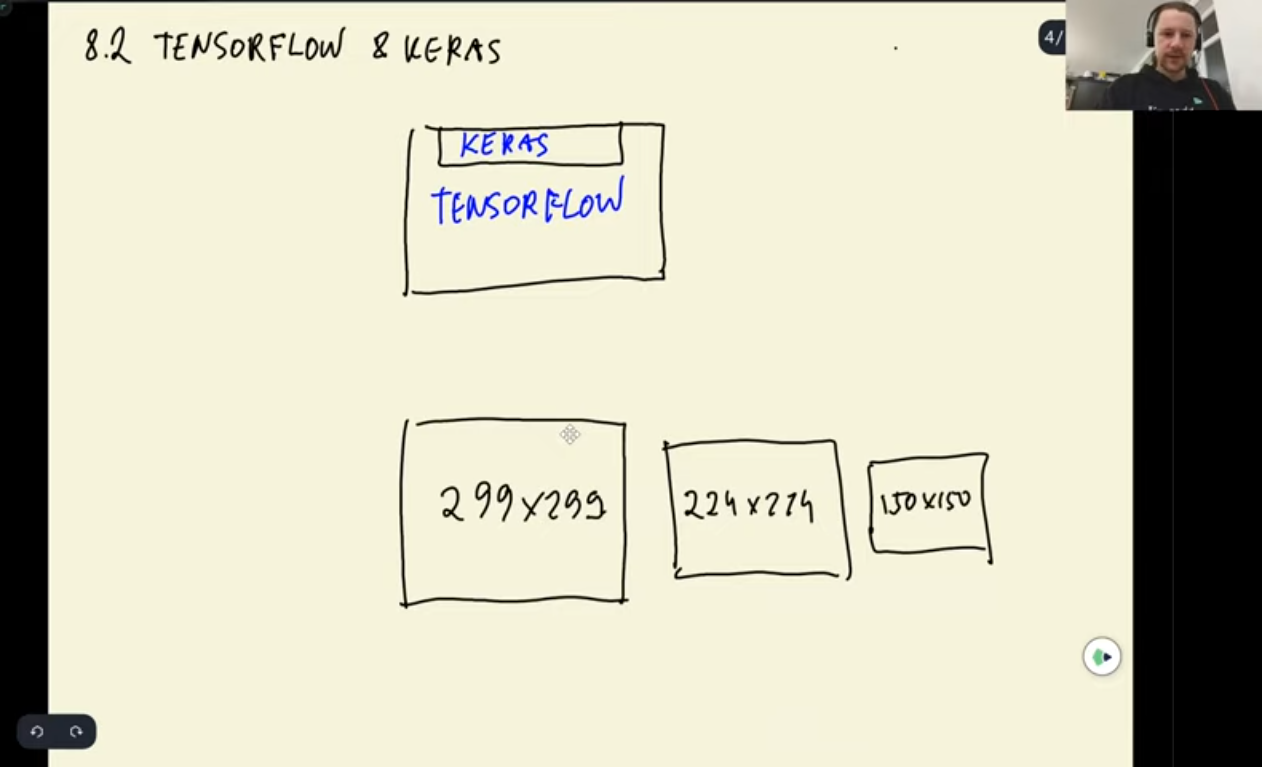

In [9]:
# Translating the image into a numpy array
x = np.array(img)
x.shape

(299, 299, 3)

In [10]:
x

array([[[179, 171,  99],
        [179, 171,  99],
        [181, 173, 101],
        ...,
        [251, 253, 248],
        [251, 253, 248],
        [251, 254, 247]],

       [[188, 179, 112],
        [187, 178, 111],
        [186, 177, 108],
        ...,
        [251, 252, 247],
        [251, 252, 247],
        [251, 252, 246]],

       [[199, 189, 127],
        [200, 190, 128],
        [200, 191, 126],
        ...,
        [250, 251, 245],
        [250, 251, 245],
        [250, 251, 245]],

       ...,

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [183, 135,  25],
        [181, 133,  22],
        [183, 135,  24]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [182, 134,  23],
        [180, 132,  21],
        [182, 134,  23]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [181, 133,  22],
        [179, 131,  20],
        [182, 134,  23]]

### 8.3 Pre-trained convolutional neural networks

Imagenet datasets: image-net.org

Pre-trained models: keras.io/api/applications

In [20]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [12]:
model = Xception(weights='imagenet', input_shape=(299,299,3))

2025-11-25 00:27:48.342209: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 169s 2us/step


In [13]:
# Putting an image into an array of images because the model expects a batch of images
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [18]:
# The image should be preprocessed to make sense
X = preprocess_input(X)

In [17]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[3.23712302e-04, 1.57383896e-04, 2.13493287e-04, 1.52370572e-04,
        2.47626333e-04, 3.05035966e-04, 3.20592400e-04, 1.47499362e-04,
        2.03621923e-04, 1.49272484e-04, 1.95663175e-04, 2.10137499e-04,
        7.59265313e-05, 1.13972274e-04, 1.62683617e-04, 2.04638694e-04,
        1.97416230e-04, 1.44288933e-04, 1.40217555e-04, 1.73686043e-04,
        7.46690610e-04, 2.56966887e-04, 2.66808958e-04, 2.96514481e-04,
        3.73602641e-04, 2.77404353e-04, 2.16570945e-04, 2.27270240e-04,
        3.80813086e-04, 1.72166023e-04, 3.05401161e-04, 1.96431400e-04,
        3.92115151e-04, 4.78071859e-04, 2.91751436e-04, 3.25693487e-04,
        1.47395302e-04, 1.62362150e-04, 2.12710656e-04, 1.34028320e-04,
        2.40070614e-04, 6.75212184e-04, 2.54943705e-04, 1.44478807e-04,
        4.12821537e-04, 2.04408745e-04, 3.02958302e-04, 1.49339685e-04,
        1.99653805e-04, 2.27005963e-04, 2.93729419e-04, 2.27444776e-04,
        6.37644727e-04, 7.82616087e-04, 2.49557430e-04, 4.052708

In [19]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [22]:
# Deoding predictions for human-readable format
decode_predictions(pred)

[[('n02667093', 'abaya', np.float32(0.02869497)),
  ('n04418357', 'theater_curtain', np.float32(0.02071707)),
  ('n01930112', 'nematode', np.float32(0.015742684)),
  ('n03691459', 'loudspeaker', np.float32(0.0139602395)),
  ('n03196217', 'digital_clock', np.float32(0.012880169))]]